In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import anderson, shapiro
import scipy.stats as stats

df = pd.read_csv('company_esg_financial_dataset.csv')

In [140]:
print(df.shape)


(11000, 16)


In [141]:
df

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,1000,Company_1000,Consumer Goods,Latin America,2021,3419.2,21.7,14416.7,0.4,52.2,67.2,46.3,43.1,498875.8,623594.7,2494378.8
10996,1000,Company_1000,Consumer Goods,Latin America,2022,3518.8,21.4,8078.9,2.9,51.9,68.7,44.7,42.3,506013.7,632517.1,2530068.4
10997,1000,Company_1000,Consumer Goods,Latin America,2023,3417.1,17.1,13263.4,-2.9,52.9,72.4,43.1,43.2,473561.5,591951.9,2367807.7
10998,1000,Company_1000,Consumer Goods,Latin America,2024,3183.2,15.7,6960.1,-6.8,52.0,72.4,40.5,42.9,441310.9,551638.6,2206554.3


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [143]:
df.duplicated().sum()

0

In [144]:
df.isnull().sum()

CompanyID               0
CompanyName             0
Industry                0
Region                  0
Year                    0
Revenue                 0
ProfitMargin            0
MarketCap               0
GrowthRate           1000
ESG_Overall             0
ESG_Environmental       0
ESG_Social              0
ESG_Governance          0
CarbonEmissions         0
WaterUsage              0
EnergyConsumption       0
dtype: int64

In [145]:
df_cleaned = df.dropna(subset=['GrowthRate'])

In [146]:
print(df_cleaned.isnull().sum())

CompanyID            0
CompanyName          0
Industry             0
Region               0
Year                 0
Revenue              0
ProfitMargin         0
MarketCap            0
GrowthRate           0
ESG_Overall          0
ESG_Environmental    0
ESG_Social           0
ESG_Governance       0
CarbonEmissions      0
WaterUsage           0
EnergyConsumption    0
dtype: int64


In [147]:
df_cleaned.shape

(10000, 16)

In [148]:
print(df_cleaned.dtypes)

CompanyID              int64
CompanyName           object
Industry              object
Region                object
Year                   int64
Revenue              float64
ProfitMargin         float64
MarketCap            float64
GrowthRate           float64
ESG_Overall          float64
ESG_Environmental    float64
ESG_Social           float64
ESG_Governance       float64
CarbonEmissions      float64
WaterUsage           float64
EnergyConsumption    float64
dtype: object


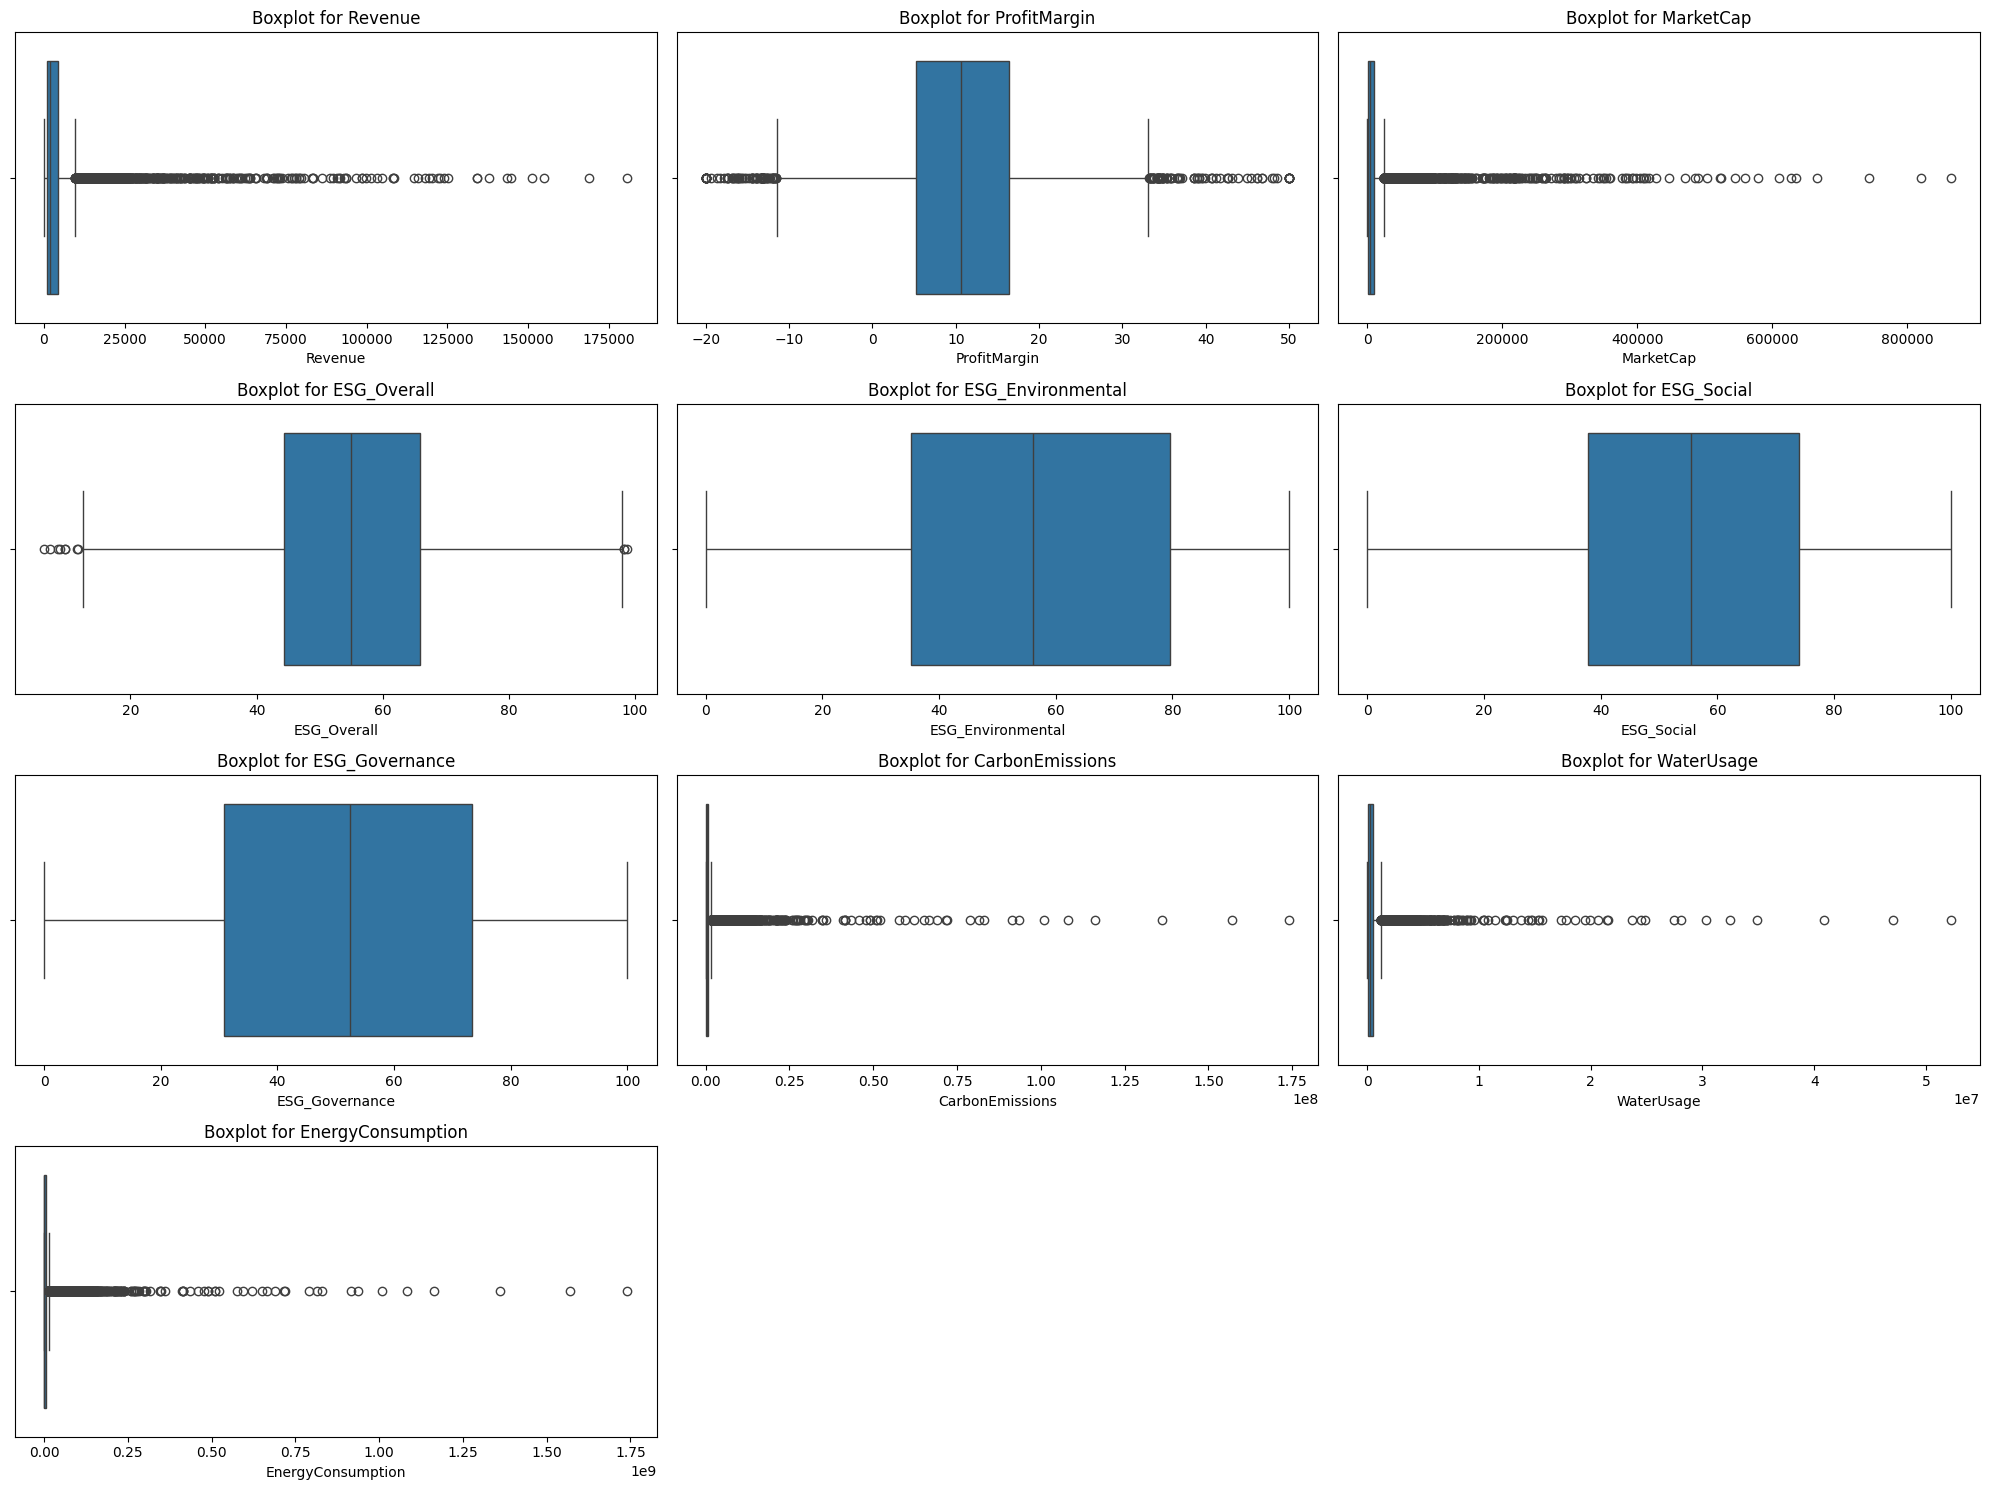

In [149]:
numeric_cols = ['Revenue', 'ProfitMargin', 'MarketCap', 
                'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 
                'ESG_Governance', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

plt.figure(figsize=(20, 15))
for idx, col in enumerate(numeric_cols):
    plt.subplot(4, 3, idx+1)
    sns.boxplot(data=df_cleaned, x=col)
    plt.title(f'Boxplot for {col}')
plt.tight_layout()
plt.show()

In [150]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

In [151]:
columns_with_outliers = ['Revenue', 'MarketCap', 'CarbonEmissions']

for col in columns_with_outliers:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)

df_cleaned = df_cleaned.reset_index(drop=True)

In [152]:
df_cleaned.shape

(7368, 16)

In [153]:
cols_to_scale = ['Revenue', 'ProfitMargin', 'MarketCap', 
                 'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 
                 'ESG_Governance', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

scaler = MinMaxScaler()
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])

In [154]:
df_cleaned[cols_to_scale]

,Revenue,ProfitMargin,MarketCap,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,0.045300,0.378462,0.022920,0.545139,0.589,0.328,0.785,0.024669,0.009295,0.002930
1,0.054724,0.387692,0.019578,0.542824,0.576,0.340,0.778,0.030049,0.011322,0.003579
2,0.054052,0.373846,0.017668,0.560185,0.623,0.334,0.783,0.028401,0.010701,0.003380
3,0.053648,0.383077,0.033696,0.543981,0.637,0.300,0.761,0.027806,0.010477,0.003309
4,0.054993,0.400000,0.024020,0.533565,0.651,0.285,0.735,0.028118,0.010595,0.003346
...,...,...,...,...,...,...,...,...,...,...
7363,0.349995,0.641538,0.905686,0.493056,0.672,0.463,0.431,0.347480,0.328127,0.104924
7364,0.360299,0.636923,0.507483,0.489583,0.687,0.447,0.423,0.352473,0.332830,0.106428
7365,0.349778,0.570769,0.833224,0.501157,0.724,0.431,0.432,0.329776,0.311450,0.099589
7366,0.325582,0.549231,0.437189,0.490741,0.724,0.405,0.429,0.307220,0.290203,0.092792


In [155]:
df_cleaned.describe()

,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000
mean,507.239414,2020.360206,0.186114,0.455543,0.212952,4.072978,0.516975,0.549832,0.556885,0.521273,0.241114,0.136685,0.117521
std,289.273703,2.860876,0.162567,0.116372,0.226326,9.125878,0.180719,0.256993,0.232952,0.252354,0.229034,0.158561,0.166116
min,1.000000,2016.000000,0.000000,0.000000,0.000000,-36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,253.000000,2018.000000,0.076215,0.380000,0.052499,-1.800000,0.398148,0.348000,0.381000,0.316000,0.065747,0.024455,0.009292
50%,507.000000,2020.000000,0.134922,0.453846,0.121576,4.100000,0.511574,0.540000,0.550000,0.523000,0.161102,0.080976,0.042057
75%,766.000000,2023.000000,0.242785,0.527692,0.298203,10.000000,0.643519,0.749000,0.733000,0.733250,0.351527,0.187346,0.155858
max,1000.000000,2025.000000,1.000000,1.000000,1.000000,35.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [156]:
correlation_matrix = df_cleaned[numeric_cols].corr()
correlation_matrix

,Revenue,ProfitMargin,MarketCap,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
Revenue,1.000000,0.114144,0.680525,0.178523,0.322010,0.032139,-0.026207,0.128972,0.300400,0.048830
ProfitMargin,0.114144,1.000000,0.446854,0.054415,0.171945,-0.043654,-0.033881,-0.116718,0.003896,-0.059626
MarketCap,0.680525,0.446854,1.000000,0.136791,0.313156,-0.028620,-0.038625,0.000017,0.163338,-0.041515
ESG_Overall,0.178523,0.054415,0.136791,1.000000,0.559977,0.662355,0.674565,-0.230175,-0.152304,-0.188004
ESG_Environmental,0.322010,0.171945,0.313156,0.559977,1.000000,0.027694,-0.004533,-0.409137,-0.291390,-0.332684
ESG_Social,0.032139,-0.043654,-0.028620,0.662355,0.027694,1.000000,0.278219,-0.009659,0.026363,0.010787
ESG_Governance,-0.026207,-0.033881,-0.038625,0.674565,-0.004533,0.278219,1.000000,-0.001654,-0.010278,-0.020121
CarbonEmissions,0.128972,-0.116718,0.000017,-0.230175,-0.409137,-0.009659,-0.001654,1.000000,0.713492,0.812325
WaterUsage,0.300400,0.003896,0.163338,-0.152304,-0.291390,0.026363,-0.010278,0.713492,1.000000,0.850875
EnergyConsumption,0.048830,-0.059626,-0.041515,-0.188004,-0.332684,0.010787,-0.020121,0.812325,0.850875,1.000000


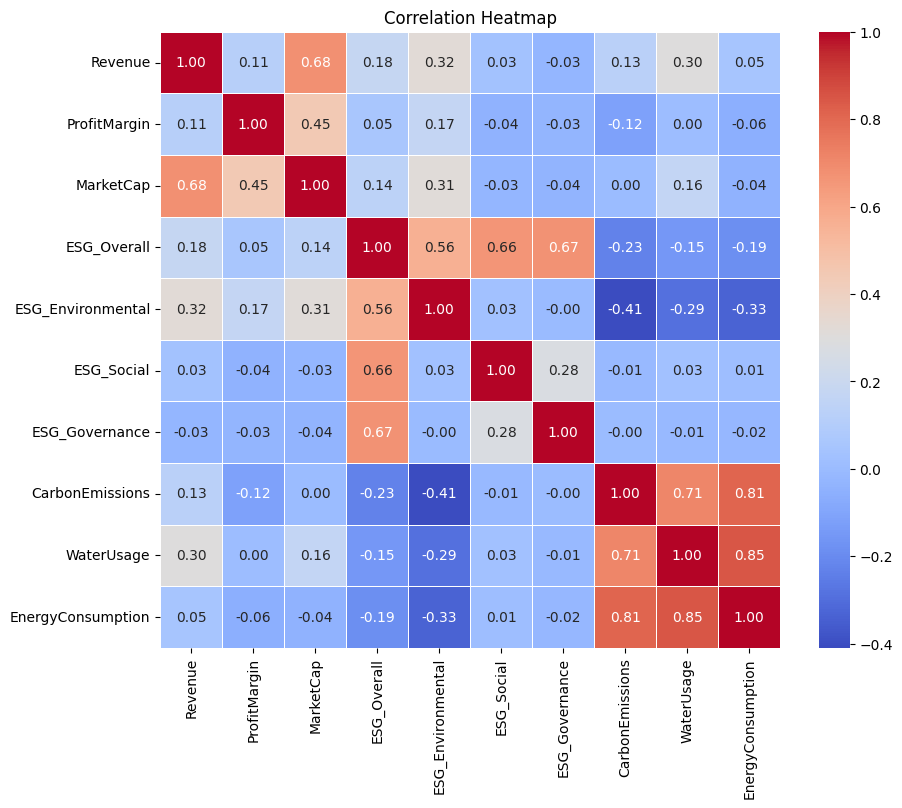

In [157]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [158]:
df_cleaned

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2016,0.045300,0.378462,0.022920,3.2,0.545139,0.589,0.328,0.785,0.024669,0.009295,0.002930
1,1,Company_1,Retail,Latin America,2017,0.054724,0.387692,0.019578,19.2,0.542824,0.576,0.340,0.778,0.030049,0.011322,0.003579
2,1,Company_1,Retail,Latin America,2018,0.054052,0.373846,0.017668,-1.1,0.560185,0.623,0.334,0.783,0.028401,0.010701,0.003380
3,1,Company_1,Retail,Latin America,2019,0.053648,0.383077,0.033696,-0.7,0.543981,0.637,0.300,0.761,0.027806,0.010477,0.003309
4,1,Company_1,Retail,Latin America,2020,0.054993,0.400000,0.024020,2.3,0.533565,0.651,0.285,0.735,0.028118,0.010595,0.003346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7363,1000,Company_1000,Consumer Goods,Latin America,2021,0.349995,0.641538,0.905686,0.4,0.493056,0.672,0.463,0.431,0.347480,0.328127,0.104924
7364,1000,Company_1000,Consumer Goods,Latin America,2022,0.360299,0.636923,0.507483,2.9,0.489583,0.687,0.447,0.423,0.352473,0.332830,0.106428
7365,1000,Company_1000,Consumer Goods,Latin America,2023,0.349778,0.570769,0.833224,-2.9,0.501157,0.724,0.431,0.432,0.329776,0.311450,0.099589
7366,1000,Company_1000,Consumer Goods,Latin America,2024,0.325582,0.549231,0.437189,-6.8,0.490741,0.724,0.405,0.429,0.307220,0.290203,0.092792


In [159]:
print("\nTop 5 Most Strongly Correlated Variable Pairs (positive or negative):")
corr_pairs = correlation_matrix.abs().unstack().sort_values(kind="quicksort", ascending=False)
strong_corr = corr_pairs[(corr_pairs < 1)].drop_duplicates().head(5)
print(strong_corr)


Top 5 Most Strongly Correlated Variable Pairs (positive or negative):
EnergyConsumption  WaterUsage           0.850875
CarbonEmissions    EnergyConsumption    0.812325
                   WaterUsage           0.713492
Revenue            MarketCap            0.680525
ESG_Overall        ESG_Governance       0.674565
dtype: float64


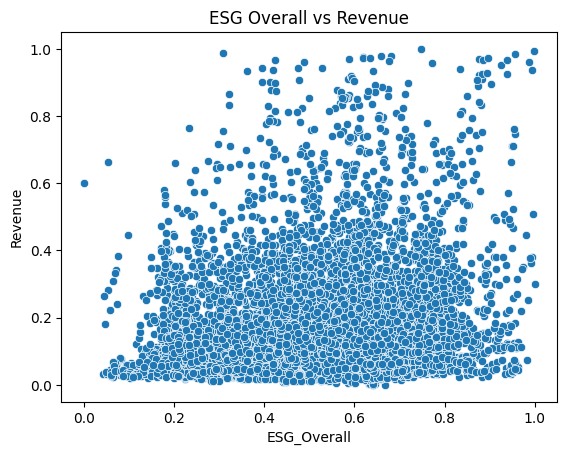

In [160]:
sns.scatterplot(data=df_cleaned, x='ESG_Overall', y='Revenue')
plt.title('ESG Overall vs Revenue')
plt.show()

In [161]:
esg_means = df_cleaned[['ESG_Environmental', 'ESG_Social', 'ESG_Governance']].mean()
print("Average values for ESG categories:")
print(esg_means)

Average values for ESG categories:
ESG_Environmental    0.549832
ESG_Social           0.556885
ESG_Governance       0.521273
dtype: float64


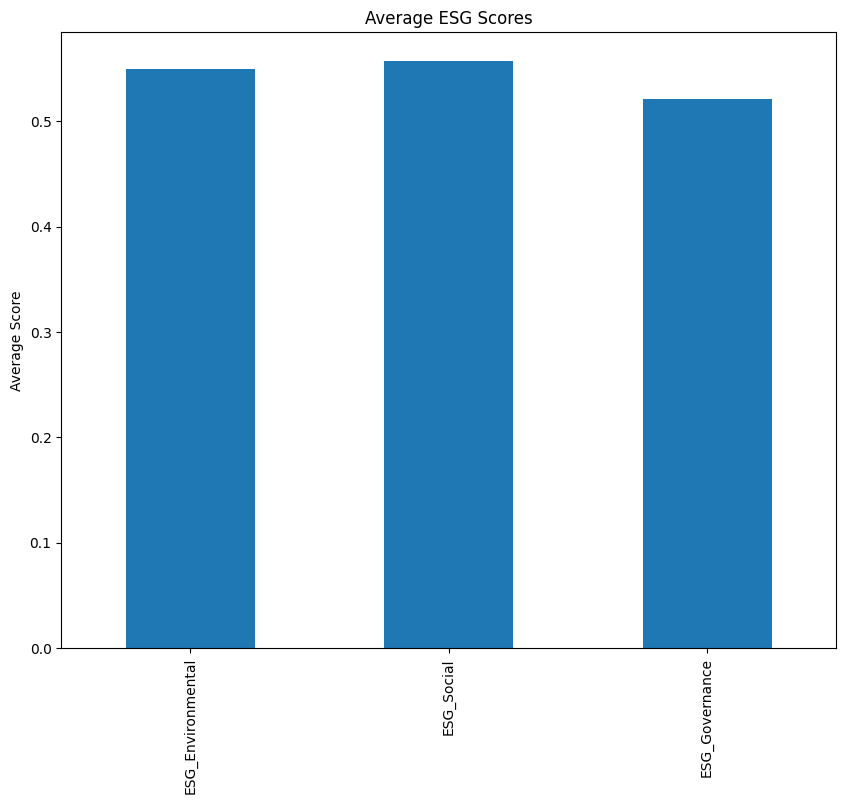

In [162]:
plt.figure(figsize=(10, 8))
df_cleaned[['ESG_Environmental', 'ESG_Social', 'ESG_Governance']].mean().plot(kind='bar')
plt.title('Average ESG Scores')
plt.ylabel('Average Score')
plt.show()

In [163]:
df_cleaned['ESG_Overall_Category'] = pd.cut(df_cleaned['ESG_Overall'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1], labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
esg_revenue_group = df_cleaned.groupby('ESG_Overall_Category',observed=False)['Revenue'].mean()

print("Average Revenue for ESG_Overall Categories:")
print(esg_revenue_group)

Average Revenue for ESG_Overall Categories:
ESG_Overall_Category
Very Low     0.142607
Low          0.152337
Medium       0.182950
High         0.207106
Very High    0.261283
Name: Revenue, dtype: float64


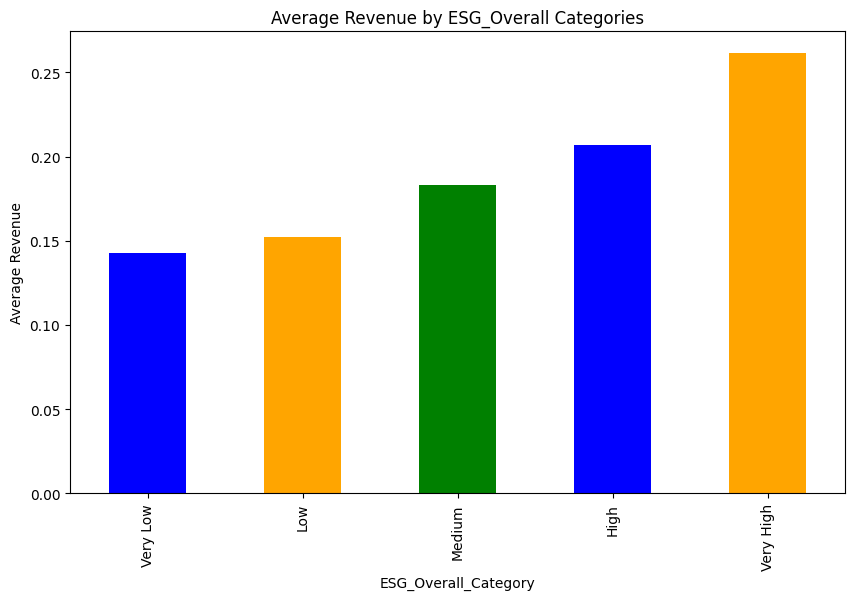

In [164]:
plt.figure(figsize=(10, 6))
esg_revenue_group.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title('Average Revenue by ESG_Overall Categories')
plt.ylabel('Average Revenue')
plt.show()

In [165]:
result = anderson(df_cleaned['Revenue'])
print(f"Statistic: {result.statistic}")
print(f"Critical values: {result.critical_values}")
print(f"Significance level: {result.significance_level}")

if result.statistic > result.critical_values[2]:
    print("The distribution is not normal.")
else:
    print("The distribution is normal.")

Statistic: 383.1737663273525
Critical values: [0.576 0.656 0.787 0.918 1.091]
Significance level: [15.  10.   5.   2.5  1. ]
The distribution is not normal.


In [166]:
print("\nSkewness (asymmetry of distribution):")
print(df_cleaned[numeric_cols].skew())


Skewness (asymmetry of distribution):
Revenue              1.989946
ProfitMargin         0.056244
MarketCap            1.530850
ESG_Overall         -0.011894
ESG_Environmental    0.065623
ESG_Social           0.024860
ESG_Governance      -0.043799
CarbonEmissions      1.283592
WaterUsage           2.063723
EnergyConsumption    2.040536
dtype: float64


In [167]:
print("\nKurtosis (peakedness of distribution):")
print(df_cleaned[numeric_cols].kurtosis())


Kurtosis (peakedness of distribution):
Revenue              4.780191
ProfitMargin         0.575595
MarketCap            1.647493
ESG_Overall         -0.392612
ESG_Environmental   -0.944780
ESG_Social          -0.817225
ESG_Governance      -1.041554
CarbonEmissions      0.916564
WaterUsage           5.017418
EnergyConsumption    4.186186
dtype: float64


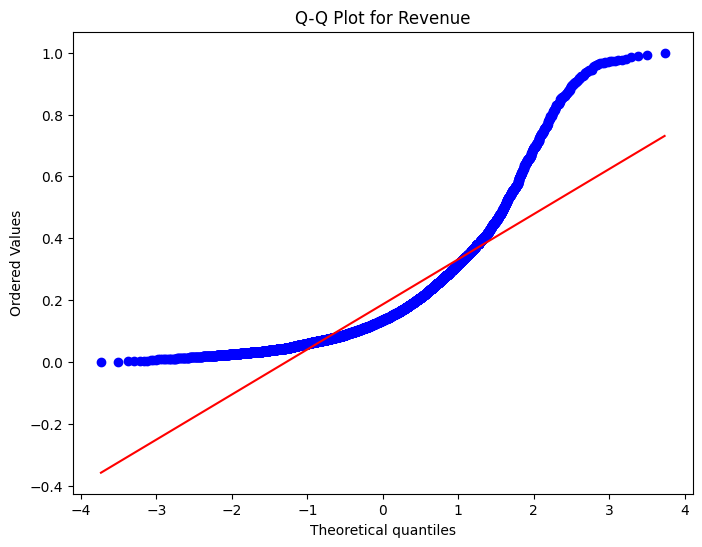

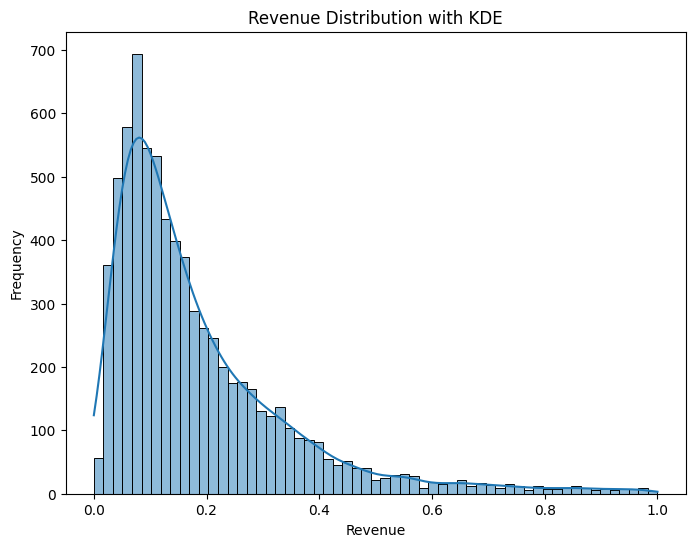

In [168]:
plt.figure(figsize=(8, 6))
stats.probplot(df_cleaned['Revenue'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Revenue')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(df_cleaned['Revenue'], kde=True, color='#1f77b4')
plt.title('Revenue Distribution with KDE')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

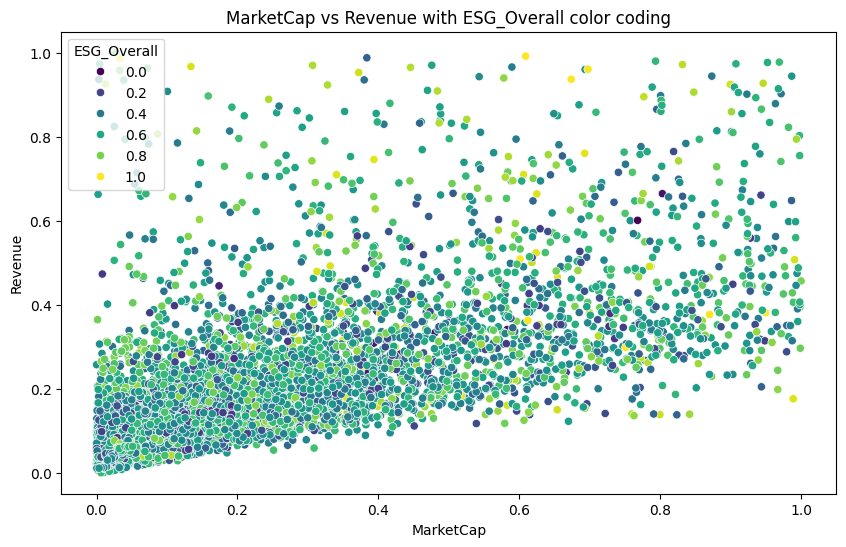

In [169]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='MarketCap', y='Revenue', hue='ESG_Overall', palette='viridis')
plt.title('MarketCap vs Revenue with ESG_Overall color coding')
plt.xlabel('MarketCap')
plt.ylabel('Revenue')
plt.show()

In [170]:
print("Correlation between ESG scores and financial performance:")
esg_financial_corr = df_cleaned[['ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'Revenue', 'ProfitMargin', 'MarketCap']].corr()
print(esg_financial_corr)

Correlation between ESG scores and financial performance:
                   ESG_Environmental  ESG_Social  ESG_Governance   Revenue  \
ESG_Environmental           1.000000    0.027694       -0.004533  0.322010   
ESG_Social                  0.027694    1.000000        0.278219  0.032139   
ESG_Governance             -0.004533    0.278219        1.000000 -0.026207   
Revenue                     0.322010    0.032139       -0.026207  1.000000   
ProfitMargin                0.171945   -0.043654       -0.033881  0.114144   
MarketCap                   0.313156   -0.028620       -0.038625  0.680525   

                   ProfitMargin  MarketCap  
ESG_Environmental      0.171945   0.313156  
ESG_Social            -0.043654  -0.028620  
ESG_Governance        -0.033881  -0.038625  
Revenue                0.114144   0.680525  
ProfitMargin           1.000000   0.446854  
MarketCap              0.446854   1.000000  


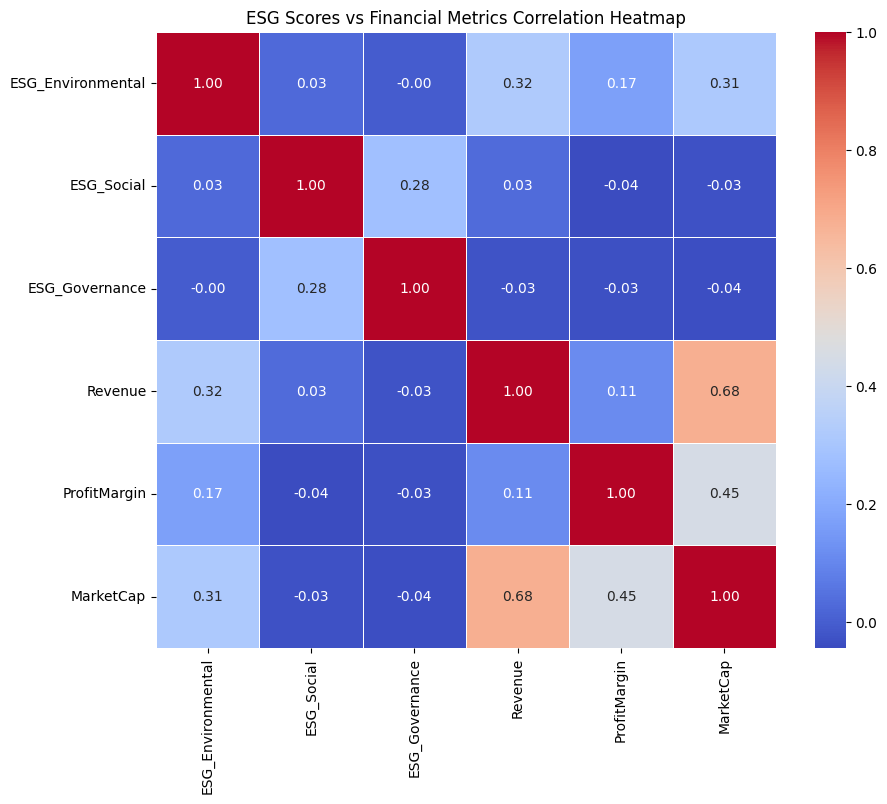

In [171]:
plt.figure(figsize=(10, 8))
sns.heatmap(esg_financial_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('ESG Scores vs Financial Metrics Correlation Heatmap')
plt.show()

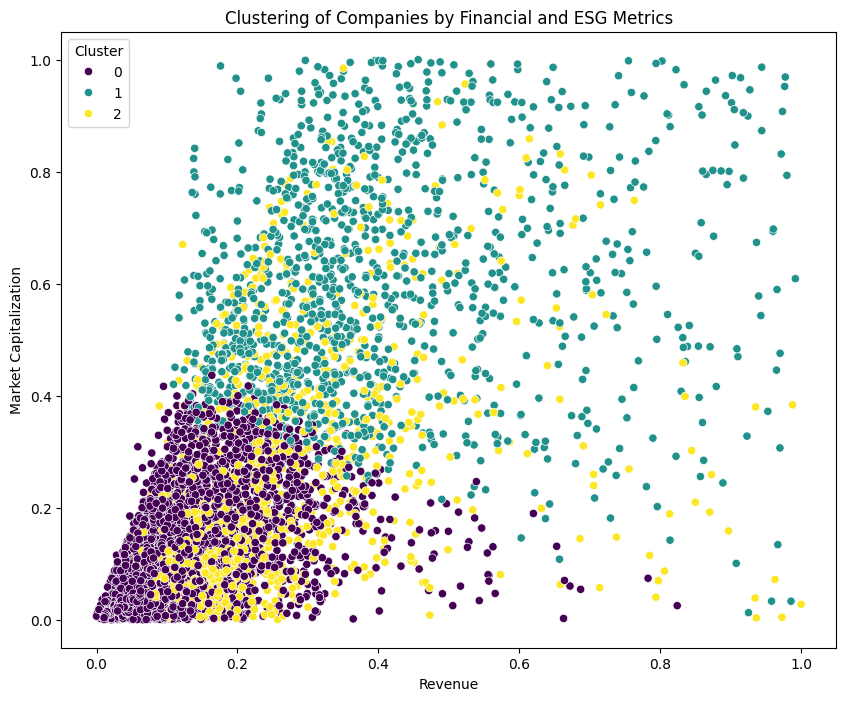

In [173]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_cleaned, x='Revenue', y='MarketCap', hue='Cluster', palette='viridis')
plt.title('Clustering of Companies by Financial and ESG Metrics')
plt.xlabel('Revenue')
plt.ylabel('Market Capitalization')
plt.show()


Region
Africa           0.160828
Asia             0.183890
Europe           0.188578
Latin America    0.193137
Middle East      0.195938
North America    0.167542
Oceania          0.208221
Name: Revenue, dtype: float64


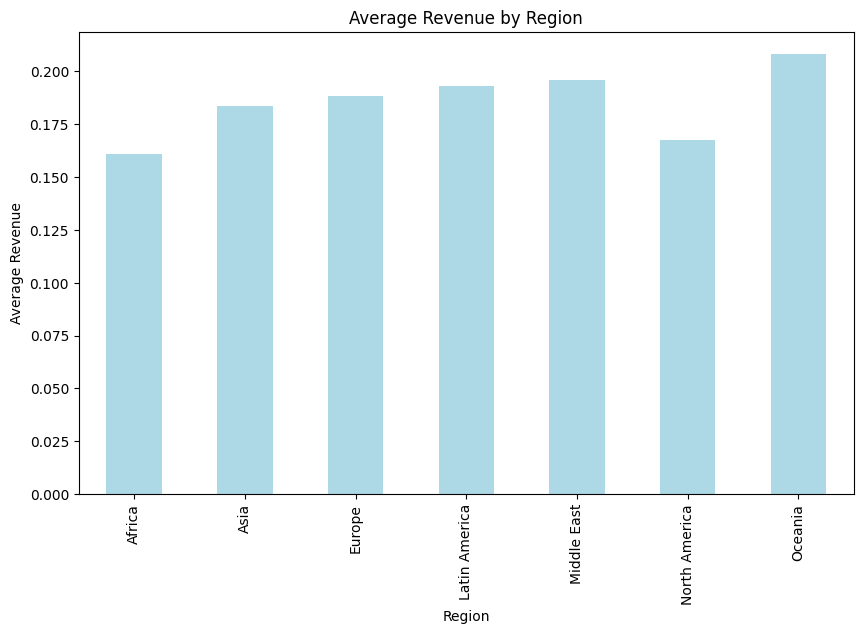

In [174]:
if 'Region' in df_cleaned.columns:
    region_revenue = df_cleaned.groupby('Region')['Revenue'].mean()
    print(region_revenue)

    plt.figure(figsize=(10, 6))
    region_revenue.plot(kind='bar', color='lightblue')
    plt.title('Average Revenue by Region')
    plt.xlabel('Region')
    plt.ylabel('Average Revenue')
    plt.show()
else:
    print("No 'Region' column found in the dataset.")